# Практика 6. t-SNE, PCA и влияние гиперпараметров

Выполнены задания из исходного блокнота:

1. исследование влияния гиперпараметров t-SNE;
2. сравнение с PCA;
3. два датасета: стандартный `Digits` и свой `txhousing` 

Для `txhousing` целевая переменная `price_segment` строится из `median`: `low`, `medium`, `high`. Затем `median` удаляется из признаков, чтобы не было утечки таргета.

## Краткая теория

t-SNE строит вероятности соседства в исходном пространстве и в 2D-пространстве, а затем минимизирует KL-дивергенцию между этими распределениями. В работе исследуются параметры `perplexity` и `learning_rate`, а результаты сравниваются с линейным методом PCA.

## Импорт библиотек и вспомогательные функции

In [4]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import pairwise_distances

RANDOM_STATE = 42

# Стратифицированная подвыборка для t-SNE, чтобы ноутбук запускался быстрее.
def stratified_sample(X, y, n_samples=800, random_state=RANDOM_STATE):
    y = np.asarray(y)
    if len(y) <= n_samples:
        return X, y
    _, X_sample, _, y_sample = train_test_split(
        X, y, test_size=n_samples, stratify=y, random_state=random_state
    )
    return X_sample, y_sample

# Единая функция запуска t-SNE.
def run_tsne(X_scaled, perplexity=30, learning_rate=200, random_state=RANDOM_STATE):
    return TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        init="pca",
        max_iter=500,
        random_state=random_state,
        n_jobs=-1
    ).fit_transform(X_scaled)

# Метрика разделения классов в 2D-проекции.
def separation_score(X_2d, y):
    y_array = np.asarray(y)
    D = pairwise_distances(X_2d)
    same = D[y_array[:, None] == y_array[None, :]]
    diff = D[y_array[:, None] != y_array[None, :]]
    return same.mean(), diff.mean(), diff.mean() / same.mean()

def plot_2d(X_2d, y, title, class_names=None):
    y = np.asarray(y)
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, s=18, cmap="tab10", alpha=0.8)
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    if class_names is not None:
        handles, _ = sc.legend_elements()
        plt.legend(handles, [str(x) for x in class_names], title="Класс", bbox_to_anchor=(1.05, 1), loc="upper left")
    else:
        plt.colorbar(sc, label="Класс")
    plt.tight_layout()
    plt.show()

def plot_counts(values, title, xlabel):
    counts = pd.Series(values).value_counts().sort_index()
    plt.figure(figsize=(7, 4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Количество")
    plt.tight_layout()
    plt.show()

def plot_corr(corr, title):
    plt.figure(figsize=(10, 8))
    im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.index)), corr.index)
    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# 1. Стандартный датасет Digits

=== DIGITS ДАТАСЕТ ===
Размер данных: (1797, 64)
Количество классов: 10
Классы: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


,count,mean,std,min,25%,50%,75%,max
pixel_0_0,1797.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
pixel_0_1,1797.0,0.303840,0.907192,0.0,0.0,0.0,0.0,8.0
pixel_0_2,1797.0,5.204786,4.754826,0.0,1.0,4.0,9.0,16.0
pixel_0_3,1797.0,11.835838,4.248842,0.0,10.0,13.0,15.0,16.0
pixel_0_4,1797.0,11.848080,4.287388,0.0,10.0,13.0,15.0,16.0
pixel_0_5,1797.0,5.781859,5.666418,0.0,0.0,4.0,11.0,16.0
pixel_0_6,1797.0,1.362270,3.325775,0.0,0.0,0.0,0.0,16.0
pixel_0_7,1797.0,0.129661,1.037383,0.0,0.0,0.0,0.0,15.0
pixel_1_0,1797.0,0.005565,0.094222,0.0,0.0,0.0,0.0,2.0
pixel_1_1,1797.0,1.993879,3.196160,0.0,0.0,0.0,3.0,16.0


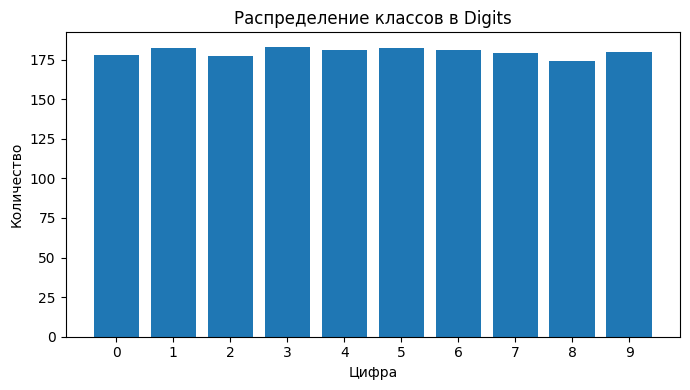

In [6]:
digits = datasets.load_digits()
X_digits = pd.DataFrame(digits.data, columns=[f"pixel_{i}_{j}" for i in range(8) for j in range(8)])
y_digits = pd.Series(digits.target, name="digit")

print("=== DIGITS ДАТАСЕТ ===")
print(f"Размер данных: {X_digits.shape}")
print(f"Количество классов: {y_digits.nunique()}")
print(f"Классы: {list(map(int, sorted(y_digits.unique())))}")

display(X_digits.head())
display(X_digits.describe().T.head(10))
plot_counts(y_digits, "Распределение классов в Digits", "Цифра")

## Нормировка Digits

In [8]:
scaler_digits = StandardScaler()
X_digits_scaled_full = scaler_digits.fit_transform(X_digits)
X_digits_scaled, y_digits_sample = stratified_sample(X_digits_scaled_full, y_digits, n_samples=800)

print(f"Размер подвыборки для визуализаций: {X_digits_scaled.shape}")
display(pd.Series(y_digits_sample).value_counts().sort_index())

Размер подвыборки для визуализаций: (800, 64)


0    79
1    81
2    79
3    81
4    81
5    81
6    81
7    80
8    77
9    80
Name: count, dtype: int64

## PCA для Digits

Доля объяснённой дисперсии: [0.11672079 0.09225126]
Суммарно: 0.20897204623656015


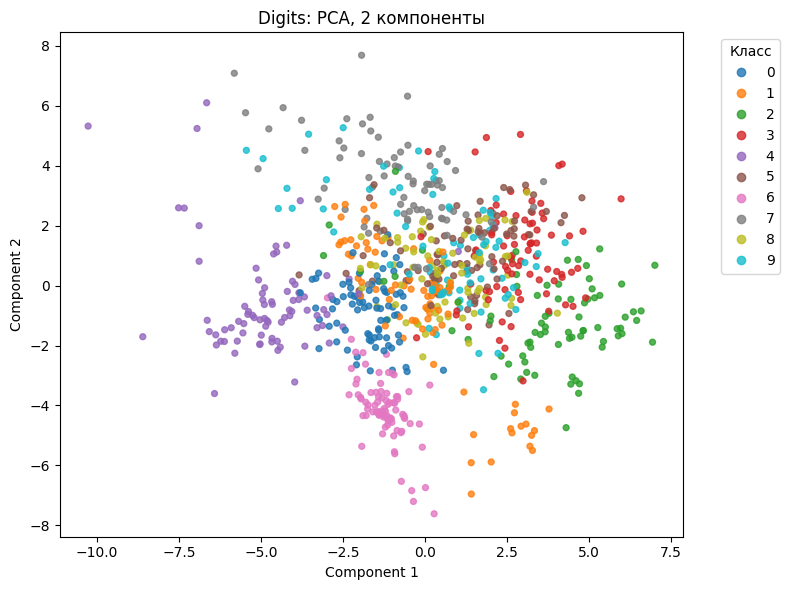

In [10]:
pca_digits = PCA(n_components=2, random_state=RANDOM_STATE)
X_digits_pca = pca_digits.fit_transform(X_digits_scaled)

print("Доля объяснённой дисперсии:", pca_digits.explained_variance_ratio_)
print("Суммарно:", pca_digits.explained_variance_ratio_.sum())
plot_2d(X_digits_pca, y_digits_sample, "Digits: PCA, 2 компоненты", class_names=list(range(10)))

## t-SNE для Digits

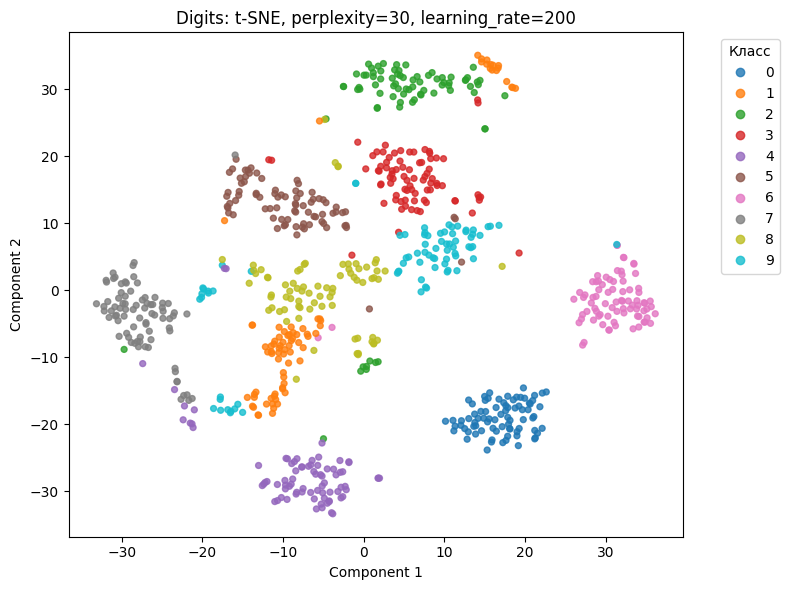

In [12]:
X_digits_tsne = run_tsne(X_digits_scaled, perplexity=30, learning_rate=200)
plot_2d(X_digits_tsne, y_digits_sample, "Digits: t-SNE, perplexity=30, learning_rate=200", class_names=list(range(10)))

## Сравнение PCA и t-SNE для Digits

In [14]:
digits_pca_same, digits_pca_diff, digits_pca_ratio = separation_score(X_digits_pca, y_digits_sample)
digits_tsne_same, digits_tsne_diff, digits_tsne_ratio = separation_score(X_digits_tsne, y_digits_sample)

digits_compare = pd.DataFrame({
    "method": ["PCA", "t-SNE"],
    "mean_distance_inside_class": [digits_pca_same, digits_tsne_same],
    "mean_distance_between_classes": [digits_pca_diff, digits_tsne_diff],
    "between/inside_ratio": [digits_pca_ratio, digits_tsne_ratio]
})
display(digits_compare)

,method,mean_distance_inside_class,mean_distance_between_classes,between/inside_ratio
0,PCA,2.515620,4.791598,1.904738
1,t-SNE,10.382076,32.426975,3.123361


## Влияние гиперпараметров t-SNE на Digits

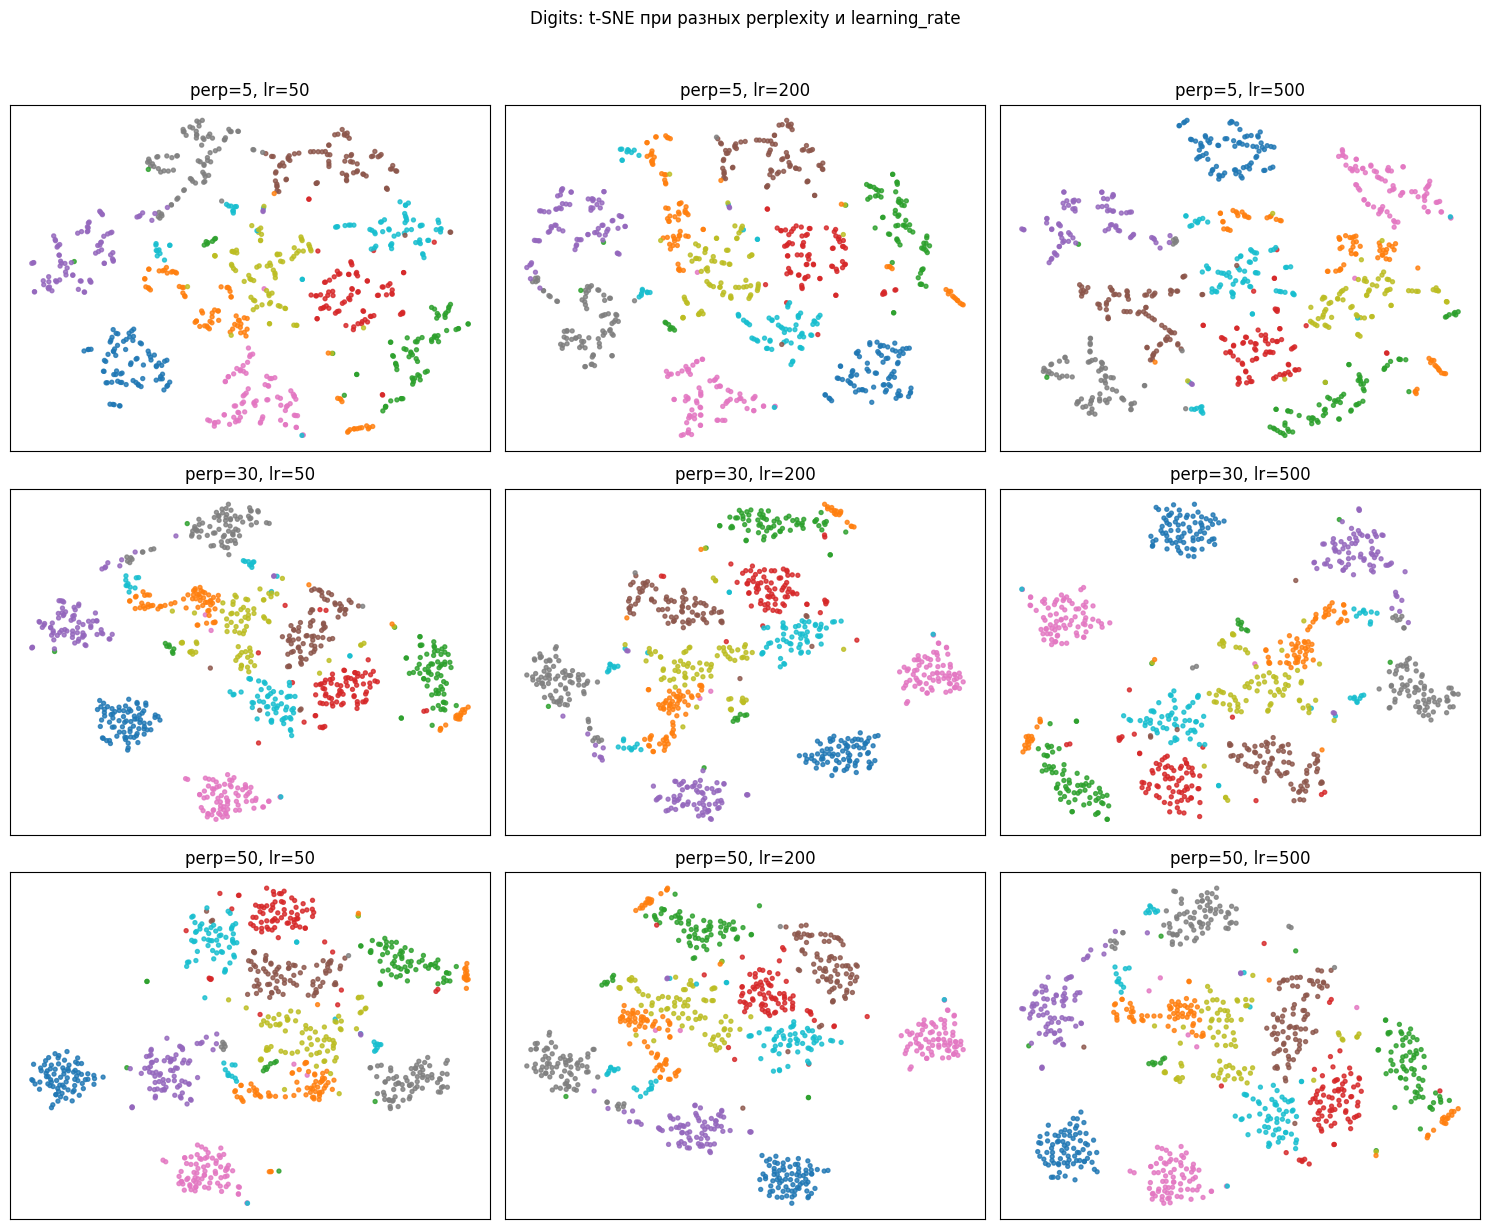

,dataset,perplexity,learning_rate,inside,between,ratio
7,Digits,50,200,6.874673,24.062963,3.500234
5,Digits,30,500,10.247504,33.424160,3.261688
6,Digits,50,50,6.962972,22.290298,3.201262
4,Digits,30,200,10.382076,32.426975,3.123361
2,Digits,5,500,17.678644,54.767353,3.097939
3,Digits,30,50,9.785811,29.618990,3.026728
0,Digits,5,50,16.628218,49.748688,2.991823
8,Digits,50,500,8.505678,24.563322,2.887873
1,Digits,5,200,18.067223,51.662846,2.859479


In [16]:
perplexities = [5, 30, 50]
learning_rates = [50, 200, 500]
fig, axes = plt.subplots(len(perplexities), len(learning_rates), figsize=(15, 12))
digits_grid_results = []

for i, perp in enumerate(perplexities):
    for j, lr in enumerate(learning_rates):
        X_emb = run_tsne(X_digits_scaled, perplexity=perp, learning_rate=lr)
        same, diff, ratio = separation_score(X_emb, y_digits_sample)
        digits_grid_results.append({"dataset": "Digits", "perplexity": perp, "learning_rate": lr, "inside": same, "between": diff, "ratio": ratio})
        ax = axes[i, j]
        ax.scatter(X_emb[:, 0], X_emb[:, 1], c=y_digits_sample, s=8, cmap="tab10", alpha=0.8)
        ax.set_title(f"perp={perp}, lr={lr}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("Digits: t-SNE при разных perplexity и learning_rate", y=1.02)
plt.tight_layout()
plt.show()
display(pd.DataFrame(digits_grid_results).sort_values("ratio", ascending=False))

### Вывод по Digits

PCA даёт устойчивую линейную проекцию, но часть классов цифр накладывается друг на друга. t-SNE лучше выделяет локальные группы. При `perplexity=5` структура чаще фрагментируется, при `perplexity=30–50` кластеры обычно стабильнее. Слишком высокий `learning_rate` может размывать и деформировать кластеры.

In [18]:
pca_digits_10 = PCA(n_components=10, random_state=RANDOM_STATE)
X_digits_pca_10 = pca_digits_10.fit_transform(X_digits_scaled)
print("Суммарная объяснённая дисперсия PCA для 10 компонент:", pca_digits_10.explained_variance_ratio_.sum())

Суммарная объяснённая дисперсия PCA для 10 компонент: 0.5994439648862753


# 2. Свой датасет txhousing: дома в Техасе

In [20]:
possible_paths = [
    Path("data/txhousing.csv")
   
]
for path in possible_paths:
    if path.exists():
        tx_path = path
        break
else:
    raise FileNotFoundError("Не найден txhousing.csv. Поместите файл в папку data рядом с ноутбуком.")

df_tx_raw = pd.read_csv(tx_path)
print("=== TXHOUSING RAW ===")
print(f"Файл: {tx_path}")
print(f"Размер исходных данных: {df_tx_raw.shape}")
display(df_tx_raw.head())
df_tx_raw.info()

=== TXHOUSING RAW ===
Файл: data\txhousing.csv
Размер исходных данных: (8602, 10)


,Unnamed: 0,city,year,month,sales,volume,median,listings,inventory,date
0,1,Abilene,2000,1,72.0,5380000.0,71400.0,701.0,6.3,2000.000000
1,2,Abilene,2000,2,98.0,6505000.0,58700.0,746.0,6.6,2000.083333
2,3,Abilene,2000,3,130.0,9285000.0,58100.0,784.0,6.8,2000.166667
3,4,Abilene,2000,4,98.0,9730000.0,68600.0,785.0,6.9,2000.250000
4,5,Abilene,2000,5,141.0,10590000.0,67300.0,794.0,6.8,2000.333333


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8602 entries, 0 to 8601
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8602 non-null   int64  
 1   city        8602 non-null   object 
 2   year        8602 non-null   int64  
 3   month       8602 non-null   int64  
 4   sales       8034 non-null   float64
 5   volume      8034 non-null   float64
 6   median      7986 non-null   float64
 7   listings    7178 non-null   float64
 8   inventory   7135 non-null   float64
 9   date        8602 non-null   float64
dtypes: float64(6), int64(3), object(1)
memory usage: 672.2+ KB


## Подготовка своего датасета

In [22]:
df_tx = df_tx_raw.copy()
df_tx = df_tx.dropna(subset=["median"]).copy()
df_tx["price_segment"] = pd.qcut(df_tx["median"], q=3, labels=["low", "medium", "high"])

feature_cols_tx = ["year", "month", "sales", "volume", "listings", "inventory", "date"]
target_col_tx = "price_segment"
df_tx_model = df_tx[feature_cols_tx + [target_col_tx]].dropna().copy()

print("Размер после удаления пропусков:", df_tx_model.shape)
print("Баланс классов до фильтра выбросов:")
display(df_tx_model[target_col_tx].value_counts())

q = 0.999
upper_bounds = df_tx_model[feature_cols_tx].quantile(q)
mask = (df_tx_model[feature_cols_tx] < upper_bounds).all(axis=1)
df_tx_model = df_tx_model.loc[mask].copy()

print(f"Размер после удаления выбросов по q={q}: {df_tx_model.shape}")
print("Баланс классов после фильтра выбросов:")
display(df_tx_model[target_col_tx].value_counts())

X_tx = df_tx_model[feature_cols_tx].copy()
y_tx_labels = df_tx_model[target_col_tx].astype(str).copy()

label_encoder_tx = LabelEncoder()
y_tx = label_encoder_tx.fit_transform(y_tx_labels)
class_names_tx = label_encoder_tx.classes_

print("Кодировка классов:")
for code, name in enumerate(class_names_tx):
    print(f"{code}: {name}")
print("Размер X и y:", X_tx.shape, y_tx.shape)

Размер после удаления пропусков: (7126, 8)
Баланс классов до фильтра выбросов:


price_segment
high      2588
medium    2392
low       2146
Name: count, dtype: int64

Размер после удаления выбросов по q=0.999: (6220, 8)
Баланс классов после фильтра выбросов:


price_segment
medium    2135
high      2131
low       1954
Name: count, dtype: int64

Кодировка классов:
0: high
1: low
2: medium
Размер X и y: (6220, 7) (6220,)


## EDA для txhousing

=== TXHOUSING DATASET ===
Размер данных: (6220, 7)
Количество классов: 3
Имена классов: ['high' 'low' 'medium']
Количество признаков: 7
Имена признаков: ['year', 'month', 'sales', 'volume', 'listings', 'inventory', 'date']


,count,mean,std,min,25%,50%,75%,max
year,6220.0,2.007577e+03,4.388738e+00,2000.0,2.004000e+03,2008.0,2011.00,2.014000e+03
month,6220.0,5.994534e+00,3.169333e+00,1.0,3.000000e+00,6.0,9.00,1.100000e+01
sales,6220.0,5.880941e+02,1.110194e+03,6.0,9.600000e+01,188.0,528.00,8.155000e+03
volume,6220.0,1.124124e+08,2.358056e+08,835000.0,1.220447e+07,26265000.0,88374177.50,2.083378e+09
listings,6220.0,3.246861e+03,5.929496e+03,0.0,6.987500e+02,1312.5,3037.25,4.121400e+04
inventory,6220.0,7.246720e+00,4.366699e+00,0.0,5.000000e+00,6.3,8.20,4.980000e+01
date,6220.0,2.007993e+03,4.398693e+00,2000.0,2.004167e+03,2008.5,2011.75,2.014833e+03


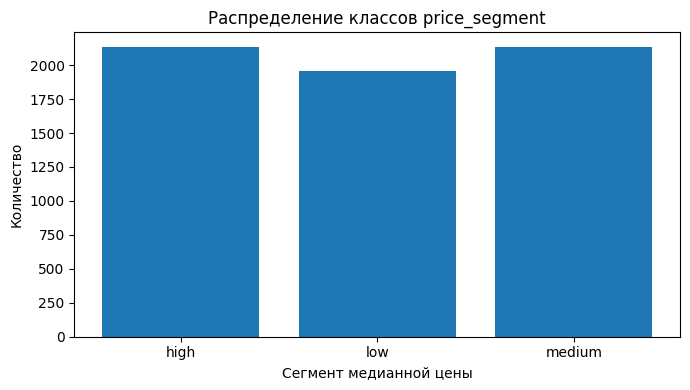

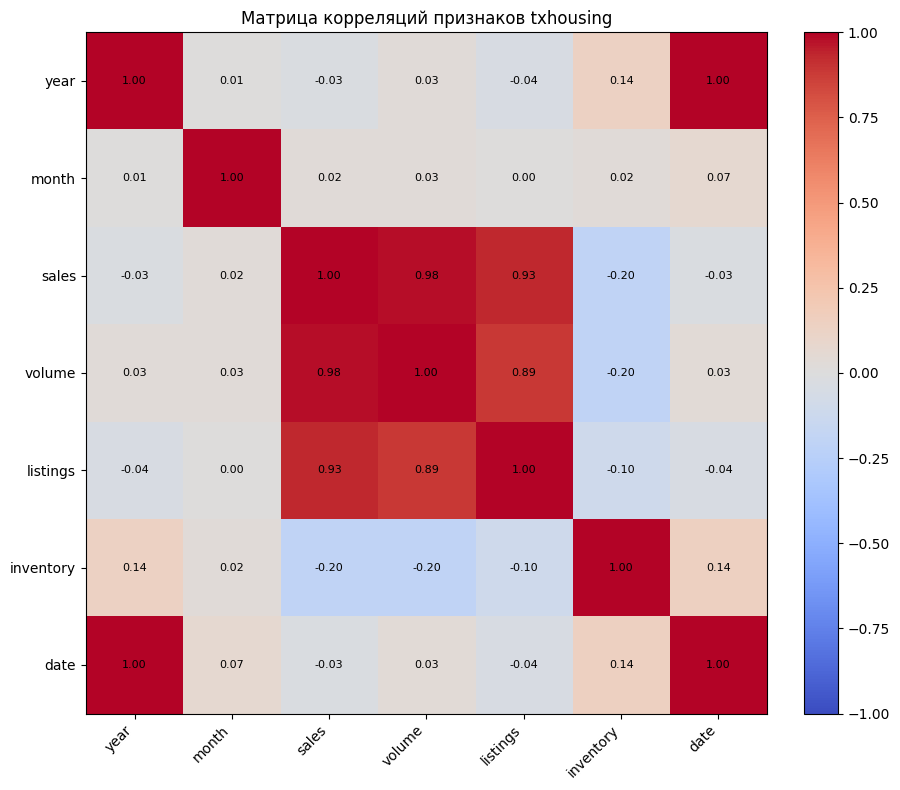

In [24]:
print("=== TXHOUSING DATASET ===")
print(f"Размер данных: {X_tx.shape}")
print(f"Количество классов: {len(class_names_tx)}")
print(f"Имена классов: {class_names_tx}")
print(f"Количество признаков: {len(feature_cols_tx)}")
print(f"Имена признаков: {feature_cols_tx}")

display(X_tx.describe().T)
plot_counts(y_tx_labels, "Распределение классов price_segment", "Сегмент медианной цены")
plot_corr(X_tx.corr(), "Матрица корреляций признаков txhousing")

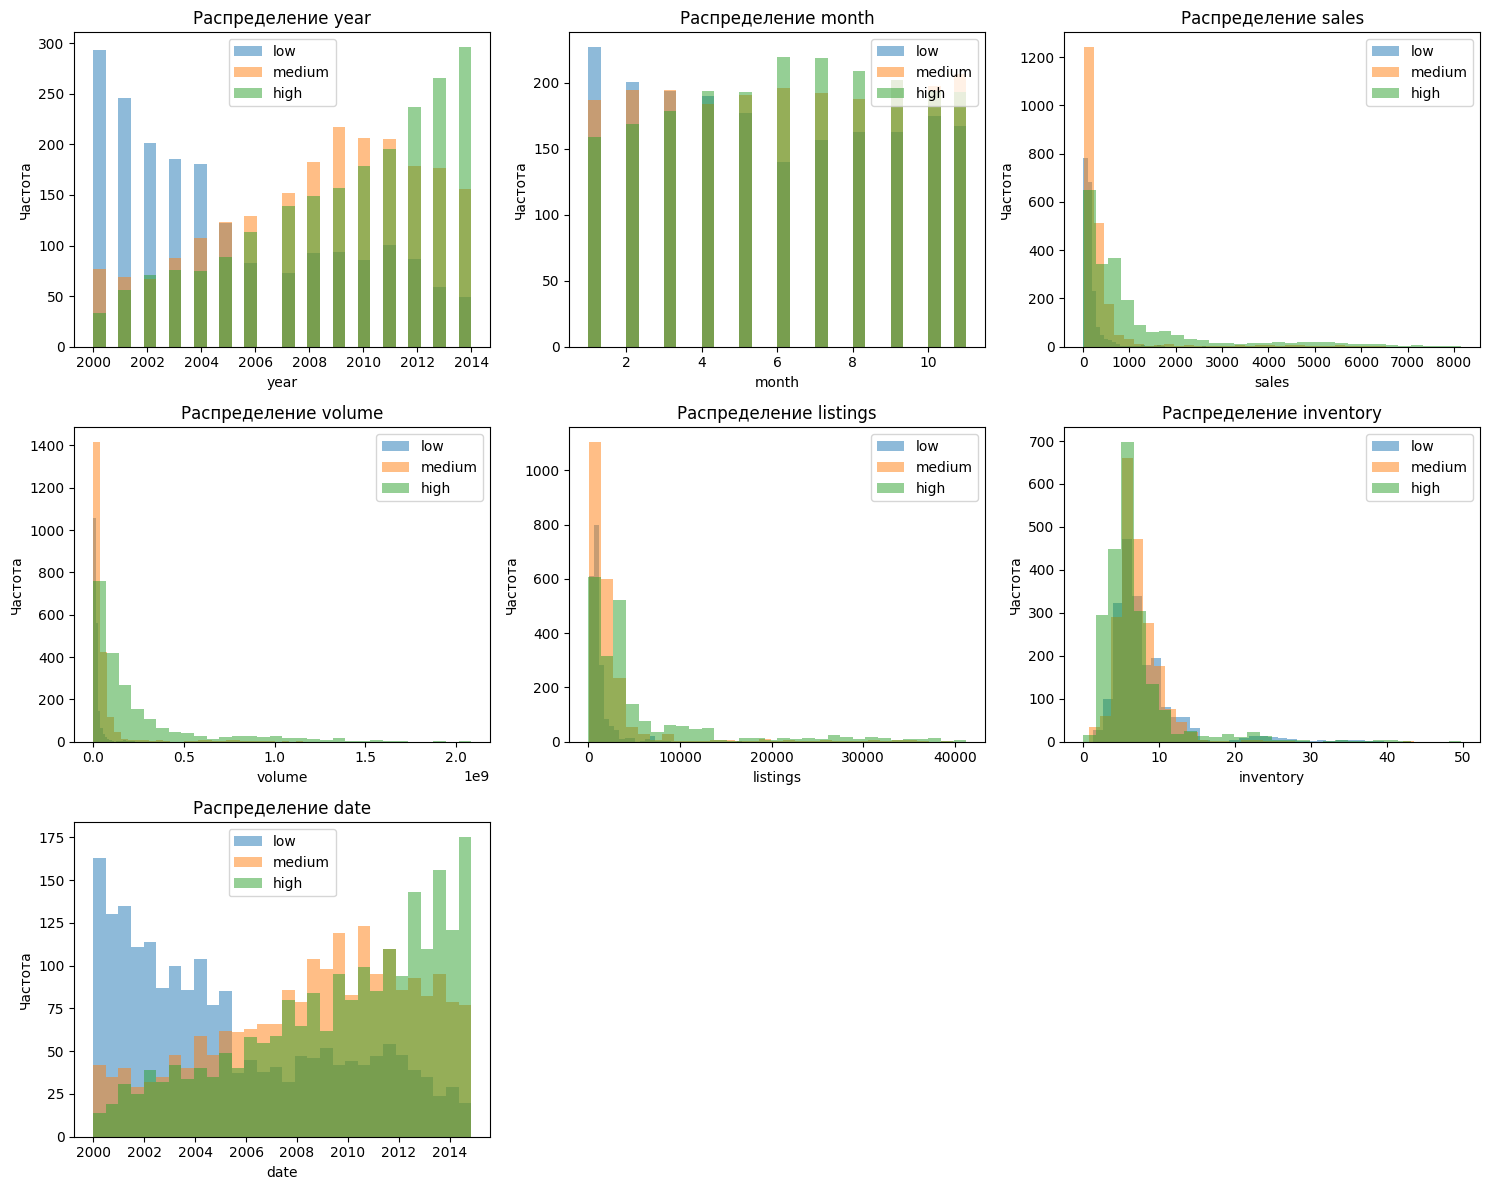

In [25]:
n_features = len(feature_cols_tx)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.ravel()

for idx, feature in enumerate(feature_cols_tx):
    ax = axes[idx]
    for cls in ["low", "medium", "high"]:
        values = df_tx_model.loc[df_tx_model[target_col_tx].astype(str) == cls, feature]
        ax.hist(values, bins=30, alpha=0.5, label=cls)
    ax.set_title(f"Распределение {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Частота")
    ax.legend()

for idx in range(len(feature_cols_tx), len(axes)):
    axes[idx].axis("off")
plt.tight_layout()
plt.show()

## Нормировка txhousing

In [27]:
scaler_tx = StandardScaler()
X_tx_scaled_full = scaler_tx.fit_transform(X_tx)
X_tx_scaled, y_tx_sample = stratified_sample(X_tx_scaled_full, y_tx, n_samples=1000)

print(f"Полный размер после подготовки: {X_tx_scaled_full.shape}")
print(f"Размер подвыборки для t-SNE/PCA-визуализаций: {X_tx_scaled.shape}")
display(pd.Series(y_tx_sample).value_counts().sort_index())

Полный размер после подготовки: (6220, 7)
Размер подвыборки для t-SNE/PCA-визуализаций: (1000, 7)


0    343
1    314
2    343
Name: count, dtype: int64

## PCA для txhousing

Доля объяснённой дисперсии: [0.41483169 0.28300847]
Суммарно: 0.6978401679933102


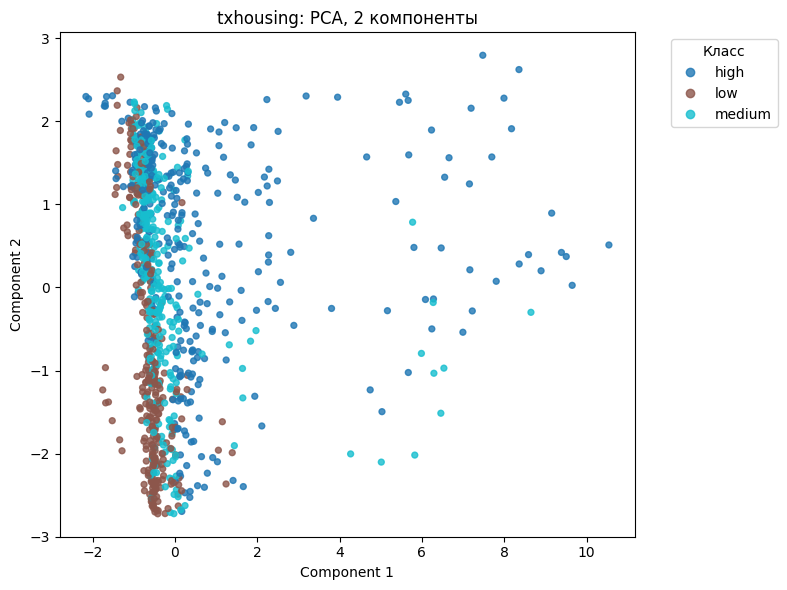

In [29]:
pca_tx = PCA(n_components=2, random_state=RANDOM_STATE)
X_tx_pca = pca_tx.fit_transform(X_tx_scaled)
print("Доля объяснённой дисперсии:", pca_tx.explained_variance_ratio_)
print("Суммарно:", pca_tx.explained_variance_ratio_.sum())
plot_2d(X_tx_pca, y_tx_sample, "txhousing: PCA, 2 компоненты", class_names=class_names_tx)

## t-SNE для txhousing

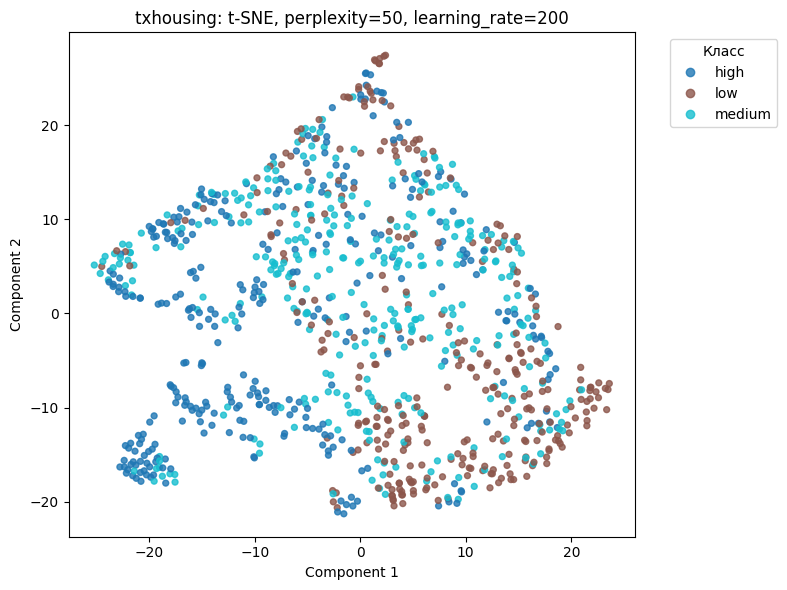

In [31]:
X_tx_tsne = run_tsne(X_tx_scaled, perplexity=50, learning_rate=200)
plot_2d(X_tx_tsne, y_tx_sample, "txhousing: t-SNE, perplexity=50, learning_rate=200", class_names=class_names_tx)

## Сравнение PCA и t-SNE для txhousing

In [33]:
tx_pca_same, tx_pca_diff, tx_pca_ratio = separation_score(X_tx_pca, y_tx_sample)
tx_tsne_same, tx_tsne_diff, tx_tsne_ratio = separation_score(X_tx_tsne, y_tx_sample)

tx_compare = pd.DataFrame({
    "method": ["PCA", "t-SNE"],
    "mean_distance_inside_class": [tx_pca_same, tx_tsne_same],
    "mean_distance_between_classes": [tx_pca_diff, tx_tsne_diff],
    "between/inside_ratio": [tx_pca_ratio, tx_tsne_ratio]
})
display(tx_compare)

,method,mean_distance_inside_class,mean_distance_between_classes,between/inside_ratio
0,PCA,2.186029,2.538317,1.161154
1,t-SNE,19.574869,22.276905,1.138036


## Влияние гиперпараметров t-SNE на txhousing

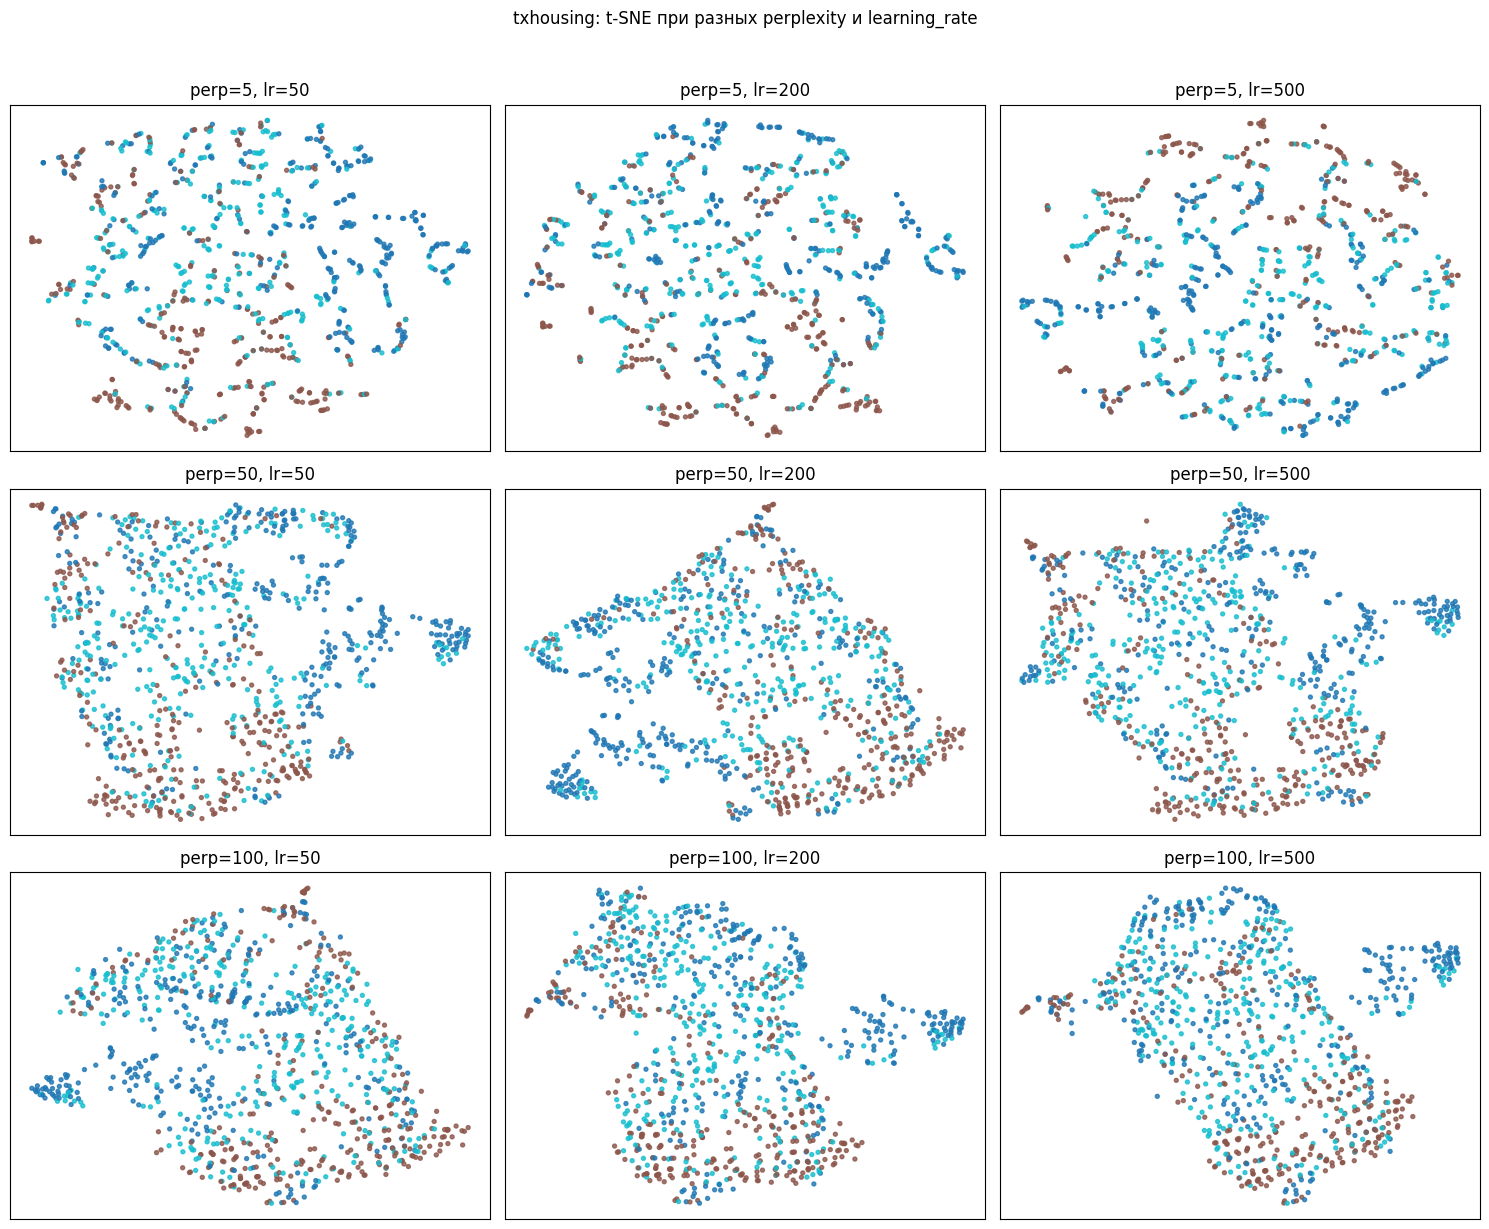

,dataset,perplexity,learning_rate,inside,between,ratio
3,txhousing,50,50,18.437355,21.051889,1.141806
4,txhousing,50,200,19.574869,22.276905,1.138036
0,txhousing,5,50,44.743576,50.850620,1.136490
7,txhousing,100,200,12.713538,14.305732,1.125236
5,txhousing,50,500,20.408712,22.763052,1.115360
6,txhousing,100,50,12.256576,13.607753,1.110241
8,txhousing,100,500,12.413280,13.673235,1.101501
1,txhousing,5,200,48.853775,53.656456,1.098307
2,txhousing,5,500,50.249149,54.473835,1.084075


In [35]:
perplexities_tx = [5, 50, 100]
learning_rates_tx = [50, 200, 500]
fig, axes = plt.subplots(len(perplexities_tx), len(learning_rates_tx), figsize=(15, 12))
tx_grid_results = []

for i, perp in enumerate(perplexities_tx):
    for j, lr in enumerate(learning_rates_tx):
        X_emb = run_tsne(X_tx_scaled, perplexity=perp, learning_rate=lr)
        same, diff, ratio = separation_score(X_emb, y_tx_sample)
        tx_grid_results.append({"dataset": "txhousing", "perplexity": perp, "learning_rate": lr, "inside": same, "between": diff, "ratio": ratio})
        ax = axes[i, j]
        ax.scatter(X_emb[:, 0], X_emb[:, 1], c=y_tx_sample, s=8, cmap="tab10", alpha=0.8)
        ax.set_title(f"perp={perp}, lr={lr}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("txhousing: t-SNE при разных perplexity и learning_rate", y=1.02)
plt.tight_layout()
plt.show()
display(pd.DataFrame(tx_grid_results).sort_values("ratio", ascending=False))

## Итоговый вывод

На `Digits` t-SNE обычно даёт более отчётливое визуальное разделение классов, потому что цифры имеют выраженную локальную структуру в пространстве пикселей. PCA устойчивее и быстрее, но сильнее смешивает классы.

На `txhousing` классы `low`, `medium`, `high` построены по медианной цене жилья, а признаки описывают рынок жилья косвенно: продажи, объём, листинги, запас, месяц и год. Поэтому идеального кластерного разделения ожидать не стоит. PCA показывает глобальную линейную структуру, а t-SNE лучше подчёркивает локальные группы, но сильнее зависит от `perplexity` и `learning_rate`.

При малой `perplexity` карта становится более дробной и может давать разрывы. При средних значениях (`30–50`) структура обычно стабильнее. Слишком большой `learning_rate` может размывать или деформировать кластеры.